In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 50

ridge_path = kagglehub.dataset_download("florianhinrichsen/ridgeregression/RidgeRegressionResults.csv")
rf_path = kagglehub.dataset_download("florianhinrichsen/randomforest/RandomForrestResults.csv")
nn_path = kagglehub.dataset_download("florianhinrichsen/neuralnetwork/NeuralNetworkResults.csv")

Loading the Results

In [ ]:
def load_data(filepath):
    """
    Loads model evaluation results from a CSV file and cleans formatting artifacts.
    
    The saved CSV files appear to contain stringified lists and numpy variable 
    representations (e.g., "['df_test']" or "[np.float64(1.5)]") rather than raw values. 
    This function strips those extra characters to extract clean labels and numerical floats.
    (AI generated)
    """
    df = pd.read_csv(filepath)

    # ---------------------------------------------------------
    # 1. Clean the Dataset labels
    # ---------------------------------------------------------
    # Remove leading list brackets and quotes (e.g., "['df_...")
    df["Dataset"] = df["Dataset"].astype(str).str.replace(r"\['df_", "", regex=True)
    # Remove trailing quotes and brackets (e.g., "...']")
    df["Dataset"] = df["Dataset"].str.replace(r"'\]", "", regex=True)
    # Remove any standalone 'df_' prefixes that might remain
    df["Dataset"] = df["Dataset"].str.replace("df_", "", regex=False)
    
    # ---------------------------------------------------------
    # 2. Clean the evaluation metrics (RMSE & MAE)
    # ---------------------------------------------------------
    # Target and remove the literal strings "[np.float64(", ")]", "[", and "]"
    # using regex, then convert the remaining clean numerical string to a float.
    df["RMSE"] = df["RMSE"].astype(str).str.replace(r"\[np\.float64\(|\)\]|\[|\]", "", regex=True).astype(float)
    df["MAE"] = df["MAE"].astype(str).str.replace(r"\[np\.float64\(|\)\]|\[|\]", "", regex=True).astype(float)

    # Return the columns as individual lists for downstream plotting or comparison
    return df["Dataset"].to_list(), df["RMSE"].to_list(), df["MAE"].to_list()


# ---------------------------------------------------------
# 3. Data Ingestion: Load Results for Each Model
# ---------------------------------------------------------
# Load Ridge Regression performance metrics
labels, rmse_ridge, mae_ridge = load_data(ridge_path)

# Load Random Forest performance metrics
labels, rmse_rf, mae_rf = load_data(rf_path)

# Load Neural Network performance metrics
labels, rmse_nn, mae_nn = load_data(nn_path)

RMSE Scores across Datasets

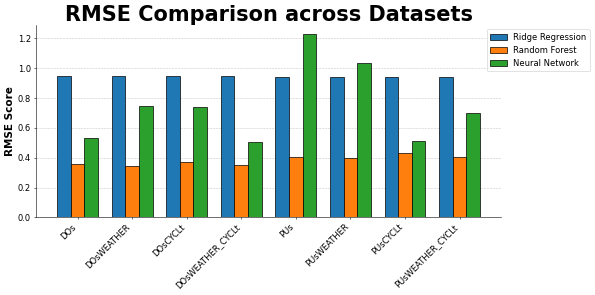

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Plot Setup & X-Axis Configuration
# ---------------------------------------------------------
# Create an array of indices for the x-axis to represent the 8 datasets
x = np.arange(8)

# Initialize the figure and axes with dimensions suited for a document/report
fig, ax = plt.subplots(figsize=(12, 6))

# ---------------------------------------------------------
# 2. Grouped Bar Chart Generation
# ---------------------------------------------------------
# Plot each model's RMSE side-by-side using coordinate offsets.
# A bar width of 0.25 allows all three models to fit seamlessly around each x-tick.
# (AI generated)
ax.bar(x - 0.25, rmse_ridge, 0.25, label="Ridge Regression", edgecolor="black")
ax.bar(x,        rmse_rf,    0.25, label="Random Forest",    edgecolor="black")
ax.bar(x + 0.25, rmse_nn,    0.25, label="Neural Network",   edgecolor="black")

# ---------------------------------------------------------
# 3. Text Formatting & Axes Labels
# ---------------------------------------------------------
ax.set_title("RMSE Comparison across Datasets", fontsize=30, fontweight="bold")
ax.set_ylabel("RMSE Score", fontsize=15, fontweight="bold")

# Apply the cleaned dataset labels to the x-axis and angle them for readability
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# Position the legend outside the main plot area so it doesn't obscure the bars
ax.legend(title="", fontsize=12, loc="best", bbox_to_anchor=(1.2, 1))

# ---------------------------------------------------------
# 4. Layout Optimization & Export
# ---------------------------------------------------------
# Add a dashed horizontal grid and ensure it renders behind the bar elements
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# Adjust padding automatically to prevent label or legend clipping
fig.tight_layout()

# Save the visualization in vector (PDF) format for high-quality report integration
#plt.savefig("RMSE_values.pdf", dpi=300)
plt.show()

MAE Scores across Datasets

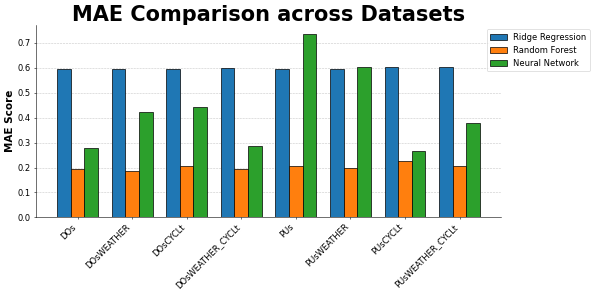

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Plot Setup & X-Axis Configuration
# ---------------------------------------------------------
# Create an array of indices for the x-axis to represent the 8 datasets
x = np.arange(8)

# Initialize the figure and axes with dimensions suited for a document/report
fig, ax = plt.subplots(figsize=(12, 6))

# ---------------------------------------------------------
# 2. Grouped Bar Chart Generation (MAE)
# ---------------------------------------------------------
# Plot each model's Mean Absolute Error (MAE) side-by-side using coordinate offsets.
# A bar width of 0.25 allows all three models to align neatly around each x-tick.
# (AI generated)
ax.bar(x - 0.25, mae_ridge, 0.25, label="Ridge Regression", edgecolor="black")
ax.bar(x,        mae_rf,    0.25, label="Random Forest",    edgecolor="black")
ax.bar(x + 0.25, mae_nn,    0.25, label="Neural Network",   edgecolor="black")

# ---------------------------------------------------------
# 3. Text Formatting & Axes Labels
# ---------------------------------------------------------
# Set clear titles and labels indicating this plot represents MAE scores
ax.set_title("MAE Comparison across Datasets", fontsize=30, fontweight="bold")
ax.set_ylabel("MAE Score", fontsize=15, fontweight="bold")

# Apply the cleaned dataset labels to the x-axis and angle them for readability
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# Position the legend outside the main plot area to prevent overlapping with the data
ax.legend(title="", fontsize=12, loc="upper right", bbox_to_anchor=(1.2, 1))

# ---------------------------------------------------------
# 4. Layout Optimization & Export
# ---------------------------------------------------------
# Add a dashed horizontal grid and ensure it renders behind the bar elements
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# Adjust padding automatically so the rotated x-labels and legend are not clipped
fig.tight_layout()

# Save the visualization in vector (PDF) format for high-quality report integration
#plt.savefig("MAE_values.pdf", dpi=300)
plt.show()

Tuning, Training and Testing times across different datasets and algorithms

In [5]:
import pandas as pd

def load_data(filepath):
    """
    Loads model tuning performance data from a CSV file and cleans formatting artifacts.
    
    Extracts the dataset names and their corresponding hyperparameter tuning 
    times (in seconds), stripping out stringified list brackets and prefix artifacts 
    left over from the data export process.
    (AI generated)
    """
    df = pd.read_csv(filepath)

    # ---------------------------------------------------------
    # 1. Clean the 'Dataset' labels
    # ---------------------------------------------------------
    # Remove leading list brackets and quotes (e.g., "['df_...")
    df["Dataset"] = df["Dataset"].astype(str).str.replace(r"\['df_", "", regex=True)
    
    # Remove trailing quotes and brackets (e.g., "...']")
    df["Dataset"] = df["Dataset"].str.replace(r"'\]", "", regex=True)
    
    # Remove any standalone 'df_' prefixes that might remain
    df["Dataset"] = df["Dataset"].str.replace("df_", "", regex=False)

    # ---------------------------------------------------------
    # 2. Clean the Tuning Time metrics
    # ---------------------------------------------------------
    # Target and remove literal square brackets "[" and "]" using regex, 
    # then convert the remaining clean numerical string to a floating-point number.
    df["Tuning_Time_sec"] = df["Tuning_Time_sec"].astype(str).str.replace(r"\[|\]", "", regex=True).astype(float)

    # ---------------------------------------------------------
    # 3. Output Extraction
    # ---------------------------------------------------------
    # Return the cleaned columns as individual lists for downstream plotting
    return df["Dataset"].to_list(), df["Tuning_Time_sec"].to_list()

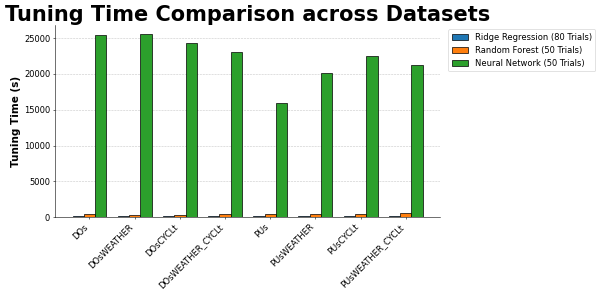

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------------------------------------------------
# 1. Data Ingestion: Load Tuning Times for Each Model
# ---------------------------------------------------------
# Extract dataset labels and hyperparameter tuning times for each evaluated model
labels, tune_ridge = load_data(ridge_path)
labels, tune_rf = load_data(rf_path)
labels, tune_nn = load_data(nn_path)

# ---------------------------------------------------------
# 2. Plot Setup & X-Axis Configuration
# ---------------------------------------------------------
# Create an array of indices for the x-axis to represent the 8 datasets
x = np.arange(8)

# Initialize the figure and axes with dimensions suited for a document/report
fig, ax = plt.subplots(figsize=(12, 6))

# ---------------------------------------------------------
# 3. Grouped Bar Chart Generation (Tuning Times)
# ---------------------------------------------------------
# Plot each model's tuning time side-by-side using coordinate offsets.
# Note: The legend explicitly notes the number of Optuna/RandomizedSearchCV 
# trials to provide context for the total time spent tuning.
# (AI generated)
ax.bar(x - 0.25, tune_ridge, 0.25, label="Ridge Regression (80 Trials)", edgecolor="black")
ax.bar(x,        tune_rf,    0.25, label="Random Forest (50 Trials)",    edgecolor="black")
ax.bar(x + 0.25, tune_nn,    0.25, label="Neural Network (50 Trials)",   edgecolor="black")

# ---------------------------------------------------------
# 4. Text Formatting & Axes Labels
# ---------------------------------------------------------
ax.set_title("Tuning Time Comparison across Datasets", fontsize=30, fontweight="bold")
ax.set_ylabel("Tuning Time (s)", fontsize=15, fontweight="bold")

# Apply the cleaned dataset labels to the x-axis and angle them for readability
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# Position the legend outside the main plot area to prevent overlapping
ax.legend(title="", fontsize=12, bbox_to_anchor=(1.01, 1), loc="upper left")

# ---------------------------------------------------------
# 5. Layout Optimization & Export
# ---------------------------------------------------------
# Add a dashed horizontal grid and ensure it renders behind the bar elements
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# Adjust padding automatically so the rotated x-labels and legend are not clipped
fig.tight_layout()

# plt.savefig("Tuning_Times.pdf", dpi=300)
plt.show()

In [7]:
import pandas as pd

def load_data(filepath):
    """
    Loads model training and testing performance data from a CSV file 
    and cleans formatting artifacts.
    
    Extracts the dataset names, training times, and testing times (in seconds), 
    stripping out stringified list brackets and prefix artifacts left over 
    from the data export process.
    (AI generated)
    """
    df = pd.read_csv(filepath)

    # ---------------------------------------------------------
    # 1. Clean the 'Dataset' labels
    # ---------------------------------------------------------
    # Remove leading list brackets and quotes (e.g., "['df_...")
    df["Dataset"] = df["Dataset"].astype(str).str.replace(r"\['df_", "", regex=True)
    
    # Remove trailing quotes and brackets (e.g., "...']")
    df["Dataset"] = df["Dataset"].str.replace(r"'\]", "", regex=True)
    
    # Remove any standalone 'df_' prefixes that might remain
    df["Dataset"] = df["Dataset"].str.replace("df_", "", regex=False)

    # ---------------------------------------------------------
    # 2. Clean the Training and Testing Time metrics
    # ---------------------------------------------------------
    # Target and remove literal square brackets "[" and "]" using regex, 
    # then convert the remaining clean numerical string to a floating-point number.
    df["Training_Time_sec"] = df["Training_Time_sec"].astype(str).str.replace(r"\[|\]", "", regex=True).astype(float)
    df["Testing_Time_sec"] = df["Testing_Time_sec"].astype(str).str.replace(r"\[|\]", "", regex=True).astype(float)

    # ---------------------------------------------------------
    # 3. Output Extraction
    # ---------------------------------------------------------
    # Return the cleaned columns as individual lists for downstream plotting
    return df["Dataset"].to_list(), df["Training_Time_sec"].to_list(), df["Testing_Time_sec"].to_list()

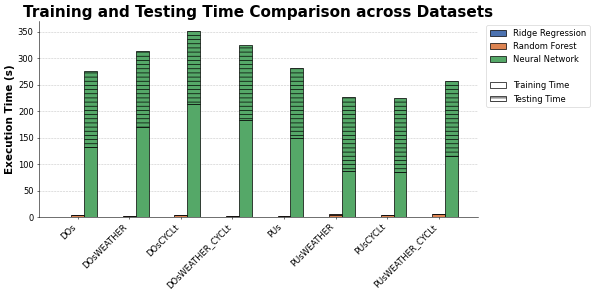

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------------------------------------------------
# 1. Data Ingestion & Preparation
# ---------------------------------------------------------
# Load execution times using the exact file paths
labels, train_ridge, test_ridge = load_data(ridge_path)
labels, train_rf, test_rf = load_data(rf_path)
labels, train_nn, test_nn = load_data(nn_path)

# Convert lists to numpy arrays to allow mathematical addition for the 'bottom' parameter in stacked bars
# (AI generated)
train_ridge, test_ridge = np.array(train_ridge), np.array(test_ridge)
train_rf, test_rf = np.array(train_rf), np.array(test_rf)
train_nn, test_nn = np.array(train_nn), np.array(test_nn)

# ---------------------------------------------------------
# 2. Plot Setup & Configuration (AI generated)
# ---------------------------------------------------------
# Create an array of indices for the x-axis to represent the datasets
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(12, 6))

# Define a distinct color palette for the models
c_ridge = "#4C72B0"  # Blue
c_rf = "#DD8452"     # Orange
c_nn = "#55A868"     # Green

# ---------------------------------------------------------
# 3. Grouped Stacked Bar Chart Generation (AI generated)
# ---------------------------------------------------------
# Plot Ridge Regression (Left) - Base is training time, hatch is testing time
ax.bar(x - 0.25, train_ridge, 0.25, color=c_ridge, edgecolor="black")
ax.bar(x - 0.25, test_ridge,  0.25, bottom=train_ridge, color=c_ridge, edgecolor="black", hatch="--")

# Plot Random Forest (Center)
ax.bar(x, train_rf, 0.25, color=c_rf, edgecolor="black")
ax.bar(x, test_rf,  0.25, bottom=train_rf, color=c_rf, edgecolor="black", hatch="--")

# Plot Neural Network (Right)
ax.bar(x + 0.25, train_nn, 0.25, color=c_nn, edgecolor="black")
ax.bar(x + 0.25, test_nn,  0.25, bottom=train_nn, color=c_nn, edgecolor="black", hatch="--")

# ---------------------------------------------------------
# 4. Text Formatting & Axes Labels
# ---------------------------------------------------------
ax.set_title("Training and Testing Time Comparison across Datasets", fontsize=22, fontweight="bold")
ax.set_ylabel("Execution Time (s)", fontsize=15, fontweight="bold")

# Apply dataset labels to the x-axis and format ticks
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# Add a dashed horizontal grid behind the bars
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# ---------------------------------------------------------
# 5. Custom Legend & Export (AI generated)
# ---------------------------------------------------------
# Construct a custom legend to explain colors (Models) and patterns (Train vs Test)
legend_elements = [
    Patch(facecolor=c_ridge, edgecolor="black", label="Ridge Regression"),
    Patch(facecolor=c_rf,    edgecolor="black", label="Random Forest"),
    Patch(facecolor=c_nn,    edgecolor="black", label="Neural Network"),
    Patch(facecolor="white", edgecolor="white", label=""),  # Invisible spacer
    Patch(facecolor="white", edgecolor="black", label="Training Time"),
    Patch(facecolor="white", edgecolor="black", hatch="--", label="Testing Time") # Fixed hatch to match plot
]

# Position the legend outside the main plot area to prevent overlap
ax.legend(handles=legend_elements, title="", fontsize=12, bbox_to_anchor=(1.01, 1), loc="upper left")

fig.tight_layout()
# plt.savefig("Train_Test_Times.pdf", dpi=300)
plt.show()